# Baseline-hit percentage by disease gene count

This notebook reads the `pocket_model_iterations/` results made by `itterations.ipynb`.

It plots:

- x-axis: number of disease-related genes / pockets, taken from folder names like `3_gene_related_disease`
- y-axis: percentage of the 100 repeats that hit the causal baseline similarity

Outputs are saved under `pocket_model_iterations/`.


In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path("/Users/miasmacbook/Desktop/kcl/6-months_project")
ITERATION_ROOT = PROJECT_ROOT / "pocket_model_iterations"

OUTPUT_CSV = ITERATION_ROOT / "hit_percent_by_gene_count.csv"
OUTPUT_PNG = ITERATION_ROOT / "hit_percent_by_gene_count.png"

print(f"Iteration root: {ITERATION_ROOT}")


Iteration root: /Users/miasmacbook/Desktop/kcl/6-months_project/pocket_model_iterations


In [2]:
summary_files = sorted(ITERATION_ROOT.glob("*_gene_related_disease/*/*_100_change_iterations_summary.csv"))
print(f"Summary files found: {len(summary_files)}")

rows = []
for path in summary_files:
    df = pd.read_csv(path)
    if df.empty:
        continue

    row = df.iloc[0].to_dict()
    folder_name = str(row.get("folder_name") or path.parents[1].name)

    match = re.match(r"(\d+)_gene_related_disease", folder_name)
    if not match:
        continue

    n_genes = int(match.group(1))
    hit_count = float(row["hit_count"])
    n_repeats = float(row["n_repeats"])
    hit_percent = (hit_count / n_repeats) * 100 if n_repeats else 0

    rows.append(
        {
            "disease_id": row["disease_id"],
            "folder_name": folder_name,
            "n_genes": n_genes,
            "hit_count": hit_count,
            "n_repeats": n_repeats,
            "hit_percent": hit_percent,
            "summary_file": path.as_posix(),
        }
    )

results_df = pd.DataFrame(rows)
if results_df.empty:
    raise ValueError(f"No iteration summary rows found under {ITERATION_ROOT}")

results_df = results_df.sort_values(["n_genes", "disease_id"]).reset_index(drop=True)
results_df.head()


Summary files found: 602


,disease_id,folder_name,n_genes,hit_count,n_repeats,hit_percent,summary_file
0,EFO_0000339,3_gene_related_disease,3,32.0,100.0,32.0,/Users/miasmacbook/Desktop/kcl/6-months_projec...
1,EFO_0000341,3_gene_related_disease,3,100.0,100.0,100.0,/Users/miasmacbook/Desktop/kcl/6-months_projec...
2,EFO_0000538,3_gene_related_disease,3,98.0,100.0,98.0,/Users/miasmacbook/Desktop/kcl/6-months_projec...
3,EFO_0000677,3_gene_related_disease,3,100.0,100.0,100.0,/Users/miasmacbook/Desktop/kcl/6-months_projec...
4,EFO_0001060,3_gene_related_disease,3,100.0,100.0,100.0,/Users/miasmacbook/Desktop/kcl/6-months_projec...


In [3]:
group_df = (
    results_df
    .groupby("n_genes", as_index=False)
    .agg(
        mean_hit_percent=("hit_percent", "mean"),
        median_hit_percent=("hit_percent", "median"),
        min_hit_percent=("hit_percent", "min"),
        max_hit_percent=("hit_percent", "max"),
        n_diseases=("disease_id", "count"),
    )
)

group_df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved grouped summary CSV: {OUTPUT_CSV}")
group_df


Saved grouped summary CSV: /Users/miasmacbook/Desktop/kcl/6-months_project/pocket_model_iterations/hit_percent_by_gene_count.csv


,n_genes,mean_hit_percent,median_hit_percent,min_hit_percent,max_hit_percent,n_diseases
0,3,91.292035,100.0,12.0,100.0,113
1,4,88.958333,100.0,8.0,100.0,72
2,5,92.564103,100.0,7.0,100.0,39
3,6,83.731707,100.0,0.0,100.0,41
4,7,89.351351,100.0,3.0,100.0,37
5,8,76.609756,96.0,2.0,100.0,41
6,9,73.848485,99.0,0.0,100.0,66
7,10,85.212766,99.0,0.0,100.0,47
8,11,92.642857,100.0,40.0,100.0,14
9,12,85.444444,93.5,2.0,100.0,18


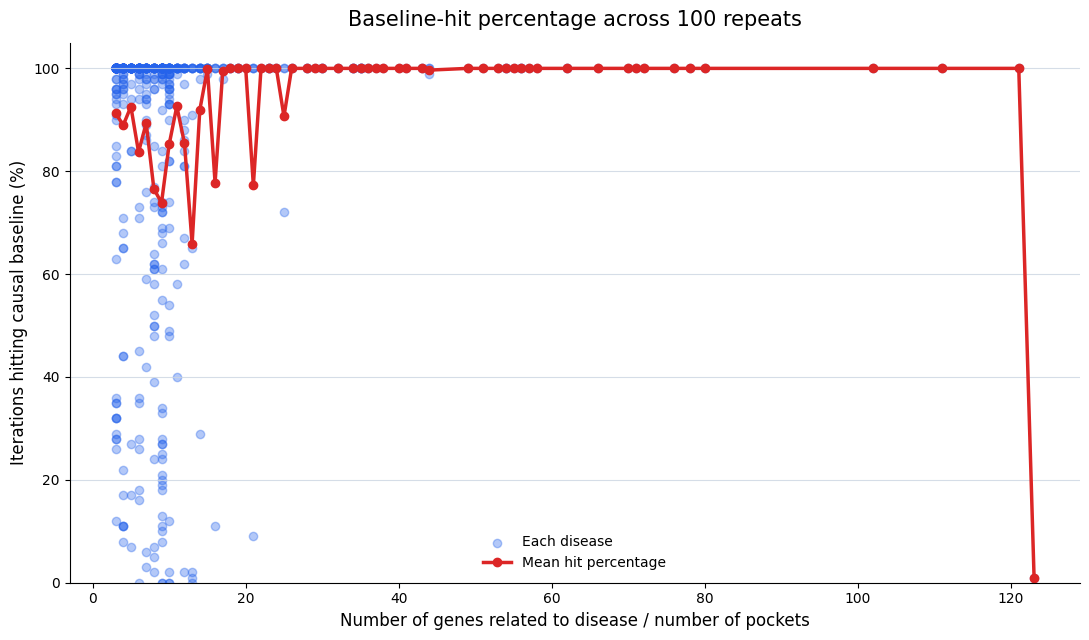

Saved graph: /Users/miasmacbook/Desktop/kcl/6-months_project/pocket_model_iterations/hit_percent_by_gene_count.png


In [4]:
fig, ax = plt.subplots(figsize=(11, 6.5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.scatter(
    results_df["n_genes"],
    results_df["hit_percent"],
    alpha=0.35,
    color="#2563eb",
    label="Each disease",
)

ax.plot(
    group_df["n_genes"],
    group_df["mean_hit_percent"],
    marker="o",
    linewidth=2.5,
    color="#dc2626",
    label="Mean hit percentage",
)

ax.set_xlabel("Number of genes related to disease / number of pockets", fontsize=12)
ax.set_ylabel("Iterations hitting causal baseline (%)", fontsize=12)
ax.set_title("Baseline-hit percentage across 100 repeats", fontsize=15, pad=12)
ax.set_ylim(0, 105)
ax.grid(True, axis="y", color="#cbd5e1", linewidth=0.8, alpha=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, loc="best")

plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=150)
plt.show()

print(f"Saved graph: {OUTPUT_PNG}")
